In [22]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

In [23]:
CUR_DIR = Path.cwd()
DEVICE_PROFILES_DIR = CUR_DIR

SCENARIOS = [
  # "50/default", 
  "300/default", 
]

AVG_NUM_SAMPLES = 1300
MODEL_SIZE_KB = 3174.0
BINS = 20

In [24]:
def load_scenario_profiles(namespace: str) -> list[dict]:
    path = DEVICE_PROFILES_DIR / namespace / "profiles.json"
    if not path.exists():
        raise FileNotFoundError(f"Missing scenario file: {path}")

    with open(path) as f:
        payload = json.load(f)

    if isinstance(payload, dict):
        return list(payload.values())
    if isinstance(payload, list):
        return payload

    raise ValueError(f"Unsupported profiles format in {path}")


def compute_delay_components(
    profiles: list[dict],
) -> tuple[list[float], list[float], list[float]]:
    compute_delays_s = [p["computation"] * AVG_NUM_SAMPLES / 1000.0 for p in profiles]
    network_delays_s = [
        (MODEL_SIZE_KB * 8 / max(1.0, p["communication"])) * 2
        for p in profiles
    ]
    total_delays_s = [c + n for c, n in zip(compute_delays_s, network_delays_s)]
    return compute_delays_s, network_delays_s, total_delays_s

In [25]:
scenario_delays = {}
for scenario in SCENARIOS:
    profiles = load_scenario_profiles(scenario)
    compute_s, network_s, total_s = compute_delay_components(profiles)
    scenario_delays[scenario] = {
        "compute": compute_s,
        "network": network_s,
        "total": total_s,
    }

for scenario, delays in scenario_delays.items():
    print(
        scenario,
        "count=", len(delays["total"]),
        "median=", f"{sorted(delays['total'])[len(delays['total'])//2]:.2f}s",
        "p75=", f"{sorted(delays['total'])[int(len(delays['total'])*0.75)]:.2f}s",
        "p90=", f"{sorted(delays['total'])[int(len(delays['total'])*0.9)]:.2f}s",
        "p95=", f"{sorted(delays['total'])[int(len(delays['total'])*0.95)]:.2f}s",
    )

300/default count= 300 median= 411.68s p75= 607.52s p90= 853.31s p95= 1005.21s


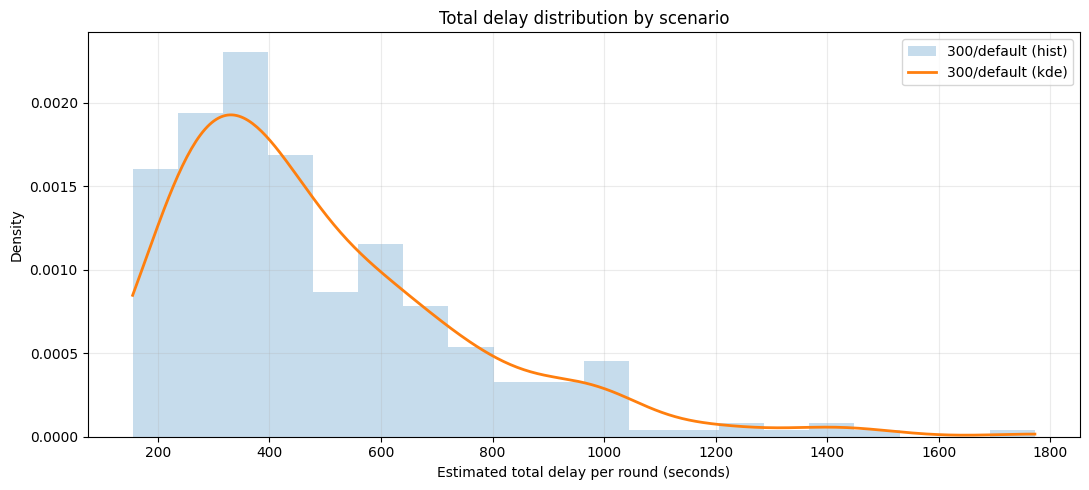

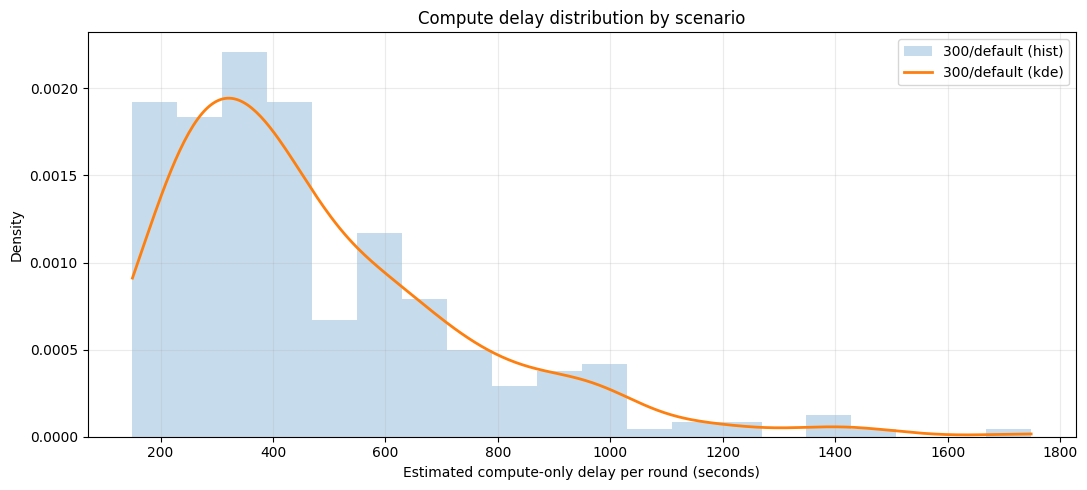

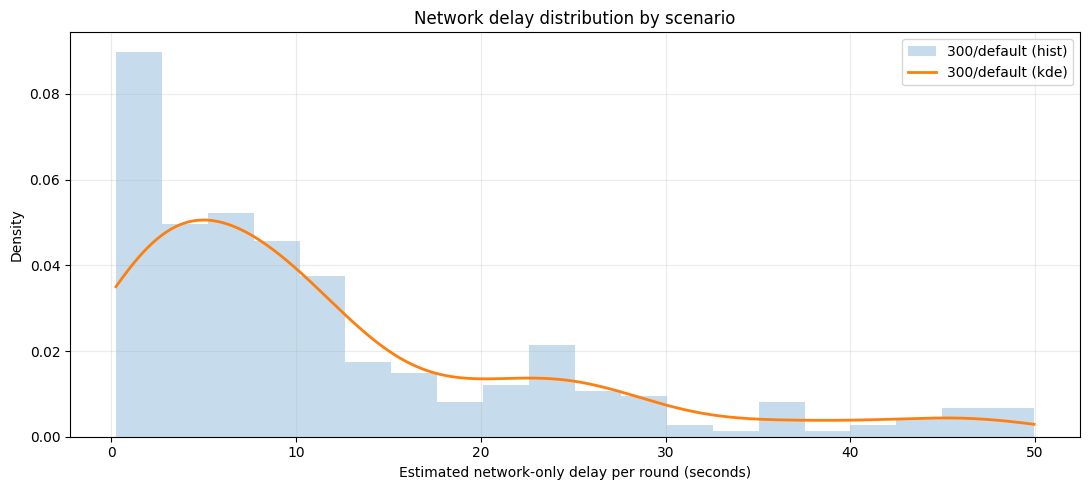

In [26]:
import numpy as np
from scipy.stats import gaussian_kde

def plot_hist_with_kde(metric_key: str, title: str, xlabel: str) -> None:
    plt.figure(figsize=(11, 5))
    for scenario in SCENARIOS:
        values = np.asarray(scenario_delays[scenario][metric_key], dtype=float)
        if values.size == 0:
            continue

        plt.hist(
            values,
            bins=BINS,
            alpha=0.25,
            density=True,
            label=f"{scenario} (hist)",
        )

        if values.size > 1 and np.std(values) > 0:
            kde = gaussian_kde(values)
            x_grid = np.linspace(values.min(), values.max(), 400)
            plt.plot(x_grid, kde(x_grid), linewidth=2.0, label=f"{scenario} (kde)")

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_hist_with_kde(
    metric_key="total",
    title="Total delay distribution by scenario",
    xlabel="Estimated total delay per round (seconds)",
)

plot_hist_with_kde(
    metric_key="compute",
    title="Compute delay distribution by scenario",
    xlabel="Estimated compute-only delay per round (seconds)",
)

plot_hist_with_kde(
    metric_key="network",
    title="Network delay distribution by scenario",
    xlabel="Estimated network-only delay per round (seconds)",
)